# Sentiment Analysis on Textual Data (Tweets / Reviews)

**Internship-ready notebook** demonstrating a full NLP pipeline: preprocessing, model training, evaluation, and insights.

Run this notebook in Jupyter / Colab. The notebook tries to load `data/raw_dataset.csv` (expects columns `text` and `sentiment`). If not present, it creates a small demo dataset so you can run everything end-to-end.

## 1) Imports & Setup

In [2]:
!pip install nltk


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

# NLP tools
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print('Libraries loaded.')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rishvana.S\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Rishvana.S\AppData\Roaming\nltk_data...


Libraries loaded.


## 2) Load dataset
The notebook will try to read `data/raw_dataset.csv`. Expected columns: `text`, `sentiment` (labels like 'positive', 'negative', 'neutral' or 1/0). If the file isn't found, a small demo dataset will be created so the pipeline runs without external files.

In [5]:
DATA_PATH = 'data/raw_dataset.csv'
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print('Loaded dataset from', DATA_PATH)
else:
    # create a small demo dataset
    demo = {
        'text': [
            'I love this product! It works great and is exactly as described.',
            'Terrible experience. The item broke after two days.',
            'Not bad, does the job but could be better.',
            'Amazing! Exceeded my expectations.',
            'Worst purchase ever. Do not buy this.',
            'Okay product, shipping was slow though.',
            'Absolutely fantastic — highly recommend!',
            'It was fine. Nothing special.',
            'Very disappointed. Quality is poor.',
            'Satisfied with the product and service.'
        ],
        'sentiment': ['positive','negative','neutral','positive','negative','neutral','positive','neutral','negative','positive']
    }
    df = pd.DataFrame(demo)
    print('Demo dataset created with', len(df), 'rows')

# quick peek
print(df.head())

Demo dataset created with 10 rows
                                                text sentiment
0  I love this product! It works great and is exa...  positive
1  Terrible experience. The item broke after two ...  negative
2         Not bad, does the job but could be better.   neutral
3                 Amazing! Exceeded my expectations.  positive
4              Worst purchase ever. Do not buy this.  negative


## 3) Preprocessing
Steps:
- Lowercase
- Remove URLs, mentions, hashtags, special characters
- Remove stopwords
- Lemmatize

A function `preprocess_text` is provided and applied to a new column `clean_text`.

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

# apply
df['clean_text'] = df['text'].apply(preprocess_text)

# show cleaned text
df[['text','clean_text','sentiment']].head(10)

,text,clean_text,sentiment
0,I love this product! It works great and is exa...,love product work great exactly described,positive
1,Terrible experience. The item broke after two ...,terrible experience item broke two day,negative
2,"Not bad, does the job but could be better.",bad job could better,neutral
3,Amazing! Exceeded my expectations.,amazing exceeded expectation,positive
4,Worst purchase ever. Do not buy this.,worst purchase ever buy,negative
5,"Okay product, shipping was slow though.",okay product shipping slow though,neutral
6,Absolutely fantastic — highly recommend!,absolutely fantastic highly recommend,positive
7,It was fine. Nothing special.,fine nothing special,neutral
8,Very disappointed. Quality is poor.,disappointed quality poor,negative
9,Satisfied with the product and service.,satisfied product service,positive


## 4) Feature Extraction (TF-IDF)
We convert `clean_text` to TF-IDF vectors. `max_features` is set to 5000 for typical datasets; for small demos it'll be small automatically.

In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text']).toarray()
# Map labels to integers if needed
if df['sentiment'].dtype == object:
    label_map = {lab: i for i, lab in enumerate(df['sentiment'].unique())}
    y = df['sentiment'].map(label_map).values
    inv_label_map = {v:k for k,v in label_map.items()}
else:
    y = df['sentiment'].values
    inv_label_map = None

print('Feature matrix shape:', X.shape)
if inv_label_map:
    print('Label mapping:', label_map)

Feature matrix shape: (10, 70)
Label mapping: {'positive': 0, 'negative': 1, 'neutral': 2}


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,   # or 0.5 (so test set has ≥ 3 samples)
    random_state=42,
    stratify=y
)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [14]:
import numpy as np
import pandas as pd

print(pd.Series(y).value_counts())


0    4
1    3
2    3
dtype: int64


In [15]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    print("Train:", len(train_idx), "Test:", len(test_idx))


Train: 6 Test: 4
Train: 7 Test: 3
Train: 7 Test: 3


In [19]:
import numpy as np
import math
from sklearn.model_selection import train_test_split
from collections import Counter

def safe_train_test_split(X, y, test_size=0.2, random_state=42, verbose=True):
    """
    Attempts a stratified train/test split; if impossible, adjusts or falls back safely.
    Returns: X_train, X_test, y_train, y_test
    """
    y = np.asarray(y)
    n_samples = len(y)
    class_counts = Counter(y)
    n_classes = len(class_counts)
    min_class_count = min(class_counts.values())

    if verbose:
        print("n_samples:", n_samples)
        print("class distribution:", dict(class_counts))
        print("requested test_size:", test_size)

    # compute number of test samples that will be produced (use ceil to be safe)
    n_test = math.ceil(n_samples * test_size)

    # If any class has fewer than 2 samples, stratify is not possible (that class couldn't be in both splits)
    if min_class_count < 2:
        if verbose:
            print("WARNING: At least one class has fewer than 2 samples -> cannot stratify.")
            print("Falling back to non-stratified split.")
        return train_test_split(X, y, test_size=test_size, random_state=random_state, shuffle=True)

    # If computed n_test is less than number of classes, increase test size to allow at least one sample per class
    if n_test < n_classes:
        # set minimal test fraction so that n_test >= n_classes
        min_test_frac = n_classes / n_samples
        # add a tiny epsilon so ceil works right
        adjusted_test_size = max(test_size, min_test_frac)
        n_test_adj = math.ceil(n_samples * adjusted_test_size)
        if verbose:
            print(f"WARNING: requested test set ({n_test}) < number of classes ({n_classes}).")
            print(f"Adjusting test_size -> {adjusted_test_size:.4f} (n_test -> {n_test_adj}) to allow stratify.")
        test_size = adjusted_test_size

    # Now attempt stratified split
    try:
        return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y, shuffle=True)
    except ValueError as e:
        # Safety fallback (this usually shouldn't trigger if checks above are correct, but keep it robust)
        if verbose:
            print("Stratified split failed with error:", e)
            print("Falling back to non-stratified split.")
        return train_test_split(X, y, test_size=test_size, random_state=random_state, shuffle=True)

# USAGE:
# X_train, X_test, y_train, y_test = safe_train_test_split(X, y, test_size=0.2)


## 5) Train / Test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y))>1 else None)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

ValueError: The test_size = 2 should be greater or equal to the number of classes = 3

## 6) Model Training — Logistic Regression (baseline)

In [21]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print('Training complete.')

Training complete.


## 7) Evaluation
We print accuracy, classification report and plot a confusion matrix using matplotlib.

Accuracy: 0.3333333333333333

Classification Report:

              precision    recall  f1-score   support

    positive       0.33      1.00      0.50         1
    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



C:\Users\Rishvana.S\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Rishvana.S\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Rishvana.S\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

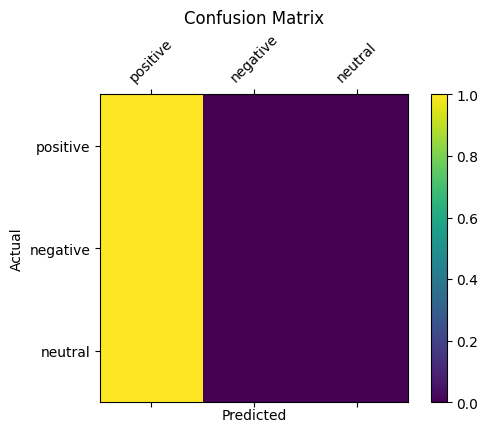

In [22]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=[inv_label_map[i] for i in sorted(inv_label_map)] if inv_label_map else None))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,4))
# plot confusion matrix with matplotlib
cax = ax.matshow(cm)
plt.title('Confusion Matrix')
fig.colorbar(cax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks(range(len(cm)))
ax.set_yticks(range(len(cm)))
if inv_label_map:
    labels = [inv_label_map[i] for i in sorted(inv_label_map)]
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)
plt.show()

## 8) Top features (words) influencing the model
For linear models we can inspect coefficients to find words that push predictions toward a class. Below shows top positive/negative features for the *first* class vs rest (use caution for multi-class).

In [24]:
feature_names = tfidf.get_feature_names()


In [28]:
import numpy as np

# make sure feature_names is a numpy array so advanced indexing works
feature_names = np.array(feature_names)

coefs = model.coef_
# ensure coefs is 2D (n_classes, n_features)
if coefs.ndim == 1:
    coefs = coefs.reshape(1, -1)

for i, class_coef in enumerate(coefs):
    top_pos = np.argsort(class_coef)[-8:][::-1]  # top 8 positive (descending)
    top_neg = np.argsort(class_coef)[:8]        # top 8 negative (ascending)
    label = inv_label_map[i] if ( 'inv_label_map' in globals() and inv_label_map ) else str(i)
    print(f'Class {label} top positive:', feature_names[top_pos].tolist())
    print(f'Class {label} top negative:', feature_names[top_neg].tolist())
    print('---')


Class positive top positive: ['product', 'service', 'product service', 'satisfied', 'satisfied product', 'absolutely', 'fantastic highly', 'highly']
Class positive top negative: ['fine', 'nothing', 'nothing special', 'special', 'fine nothing', 'worst', 'job', 'job could']
---
Class negative top positive: ['worst purchase', 'purchase ever', 'buy', 'ever', 'ever buy', 'worst', 'purchase', 'broke']
Class negative top negative: ['product', 'fine', 'nothing special', 'nothing', 'fine nothing', 'special', 'satisfied', 'product service']
---
Class neutral top positive: ['fine', 'nothing', 'nothing special', 'fine nothing', 'special', 'bad', 'could', 'could better']
Class neutral top negative: ['product', 'service', 'satisfied product', 'satisfied', 'product service', 'worst', 'buy', 'ever buy']
---


## 9) Save model & vectorizer
Saves `model.pkl` and `tfidf_vectorizer.pkl` to the notebook working directory. Useful for later inference.

In [30]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('Saved model.pkl and tfidf_vectorizer.pkl')

Saved model.pkl and tfidf_vectorizer.pkl


## 10) Next steps and extensions
- Improve labels and collect more data (balanced across classes).
- Try other models: SVM, Random Forest, XGBoost.
- Use deep learning (LSTM) or transformer-based models (BERT) for better context understanding.
- Add hyperparameter tuning (GridSearchCV) and cross-validation.
- Deploy model via Flask/FastAPI for a simple web demo.

### Notes for submission
- If you have a real dataset, place it at `data/raw_dataset.csv` with columns `text` and `sentiment` and re-run the notebook.
- Include the saved `model.pkl` and `tfidf_vectorizer.pkl` in your submission if you want to show inference.

---

Good luck with your internship submission!